In [ ]:
# Import library dasar
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Bersihkan session
tf.keras.backend.clear_session()

# Set random seed
seed_value = 42
os.environ["PYTHONHASHSEED"] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

print("Initial setup completed. Seed has been fixed and f1_score imported.")

Initial setup completed. Seed has been fixed and f1_score imported.


In [ ]:
print("Downloading dataset")

!pip install gdown -q
!gdown 1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V -O dataset_split_224.zip

print("Extracting dataset")
!rm -rf dataset_siap_pakai
!unzip -q dataset_split_224.zip -d dataset_siap_pakai

print("Dataset extracted successfully.")

Downloading...
From: https://drive.google.com/uc?id=1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V
To: /content/dataset_split_224.zip
100% 19.4M/19.4M [00:00<00:00, 33.5MB/s]
Extracting dataset
Dataset extracted successfully.


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading data...")
train_dataset_raw = image_dataset_from_directory("dataset_siap_pakai/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True, seed=seed_value)
class_names = train_dataset_raw.class_names

val_dataset_raw = image_dataset_from_directory("dataset_siap_pakai/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=False)
test_dataset_raw = image_dataset_from_directory("dataset_siap_pakai/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset_raw.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset_raw.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset_raw.prefetch(buffer_size=AUTOTUNE)

print(f"\nClass names: {class_names}")
print("Dataset pipeline optimized successfully.")

Loading data...
Found 606 files belonging to 2 classes.
Found 129 files belonging to 2 classes.
Found 131 files belonging to 2 classes.

Class names: ['AI', 'Real']
Dataset pipeline optimized successfully.


In [ ]:
def build_efficientnet_aug_model():
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal", seed=seed_value),
        layers.RandomRotation(0.05, seed=seed_value),
        layers.RandomTranslation(0.05, 0.05, seed=seed_value),
        layers.RandomZoom(0.05, seed=seed_value),
        layers.RandomContrast(0.1, seed=seed_value),
        layers.RandomBrightness(0.05, value_range=(0.0, 255.0), seed=seed_value)
    ], name="data_augmentation")

    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.3, seed=seed_value),
        layers.Dense(1, activation="sigmoid")
    ])

    return model

model_effnet_aug = build_efficientnet_aug_model()
model_effnet_aug.summary()

print("EfficientNetB0 with refined subtle augmentation model built successfully.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,972 (15.47 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

EfficientNetB0 with refined subtle augmentation model built successfully.


In [ ]:
# Training tahap 1 (tanpa fine tuning)
EPOCHS_PHASE_1 = 20
LEARNING_RATE_PHASE_1 = 0.001

metrics = [
    "accuracy",
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]

model_effnet_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_PHASE_1),
    loss="binary_crossentropy",
    metrics=metrics
)

csv_logger_1 = CSVLogger("history_skenario3_phase1.csv", append=False)

print("Starting Phase 1: Feature Extraction (Training head layers)")
history_phase1 = model_effnet_aug.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_PHASE_1,
    callbacks=[csv_logger_1]
)
print("Phase 1 completed.")

Starting Phase 1: Feature Extraction (Training head layers)
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 321ms/step - accuracy: 0.5611 - loss: 0.8883 - precision: 0.5658 - recall: 0.5248 - val_accuracy: 0.5891 - val_loss: 0.6674 - val_precision: 0.8000 - val_recall: 0.2462
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.6634 - loss: 0.6678 - precision: 0.6634 - recall: 0.6634 - val_accuracy: 0.6357 - val_loss: 0.6249 - val_precision: 0.8214 - val_recall: 0.3538
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.7195 - loss: 0.5881 - precision: 0.7138 - recall: 0.7327 - val_accuracy: 0.6899 - val_loss: 0.6040 - val_precision: 0.8571 - val_recall: 0.4615
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.7558 - loss: 0.5455 - precision: 0.7508 - recall: 0.7657 - val_accuracy: 0.7364 - val_loss: 0.5812 - val_precision: 0.8605 - val_recall: 0.5692
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.7558 - loss: 0.5221 - precision: 0.7

In [ ]:
# Setup Partial Fine-Tuning
print("Applying Fine-Tuning to the top layers")

base_model = model_effnet_aug.get_layer("efficientnetb0")
base_model.trainable = True

# Buka 30 layer terakhir agar mencakup blok MBConv utuh
total_layers = len(base_model.layers)
fine_tune_at = total_layers - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Tetap freeze Batch Normalization
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

LEARNING_RATE_PHASE_2 = 1e-5

model_effnet_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_PHASE_2),
    loss="binary_crossentropy",
    metrics=metrics
)

print(f"Model ready to train from layer {fine_tune_at} to {total_layers}.")

Applying Fine-Tuning to the top layers
Model ready to train from layer 208 to 238.


In [ ]:
# Fine-Tuning Execution
EPOCHS_PHASE_2 = 15

csv_logger_2 = CSVLogger("history_skenario3_phase2.csv", append=False)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Starting Phase 2: Partial Fine-Tuning")
history_phase2 = model_effnet_aug.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_PHASE_2,
    callbacks=[csv_logger_2, early_stop, reduce_lr]
)
print("Phase 2 Fine-Tuning completed.")

Starting Phase 2: Partial Fine-Tuning
Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 289ms/step - accuracy: 0.8663 - loss: 0.3158 - precision: 0.8676 - recall: 0.8370 - val_accuracy: 0.7984 - val_loss: 0.4958 - val_precision: 0.8095 - val_recall: 0.7846 - learning_rate: 1.0000e-05
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.8779 - loss: 0.3012 - precision: 0.8779 - recall: 0.8779 - val_accuracy: 0.7984 - val_loss: 0.4970 - val_precision: 0.8095 - val_recall: 0.7846 - learning_rate: 1.0000e-05
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.8680 - loss: 0.2908 - precision: 0.8680 - recall: 0.8680 - val_accuracy: 0.7984 - val_loss: 0.5007 - val_precision: 0.8095 - val_recall: 0.7846 - learning_rate: 1.0000e-05
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8597 - loss: 0.2930 - precision: 0.8634 - recall: 0.8514
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accura

In [ ]:
# Final Evaluation
print("SCENARIO 3 EVALUATION RESULTS ON TEST DATA (DEFAULT THRESHOLD 0.5)")

test_loss, test_accuracy, test_precision, test_recall = model_effnet_aug.evaluate(test_dataset)

if (test_precision + test_recall) == 0:
    test_f1 = 0
else:
    test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print(f"Test Loss          : {test_loss:.4f}")
print(f"Test Accuracy      : {test_accuracy:.4f}")
print(f"Test Precision     : {test_precision:.4f}")
print(f"Test Recall        : {test_recall:.4f}")
print(f"Test F1-Score      : {test_f1:.4f}")

SCENARIO 3 EVALUATION RESULTS ON TEST DATA (DEFAULT THRESHOLD 0.5)
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.8702 - loss: 0.3587 - precision: 0.8769 - recall: 0.8636
Test Loss          : 0.3587
Test Accuracy      : 0.8702
Test Precision     : 0.8769
Test Recall        : 0.8636
Test F1-Score      : 0.8702


In [ ]:
# Prediction and Metrics Table
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from IPython.display import display

y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0).flatten().astype(int)
y_pred_probs = model_effnet_aug.predict(test_dataset)

threshold_default = 0.5
y_pred = (y_pred_probs >= threshold_default).astype("int32").flatten()

print("\nEvaluation Metrics Table")
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

display(df_report)

df_report.to_csv("tabel_metrik_skenario3.csv")

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 710ms/step

Evaluation Metrics Table


,precision,recall,f1-score,support
AI,0.863636,0.876923,0.870229,65.000000
Real,0.876923,0.863636,0.870229,66.000000
accuracy,0.870229,0.870229,0.870229,0.870229
macro avg,0.870280,0.870280,0.870229,131.000000
weighted avg,0.870330,0.870229,0.870229,131.000000


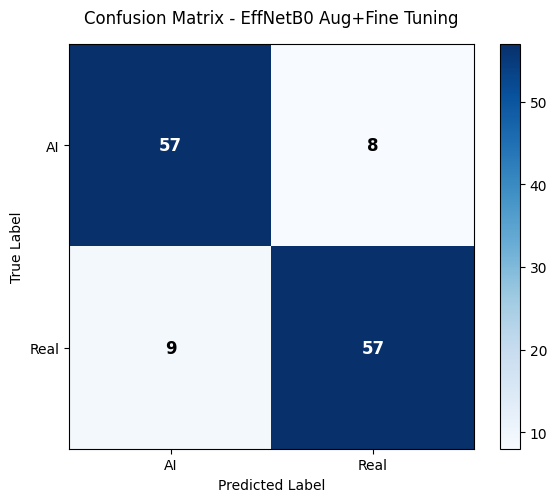

In [ ]:
# Creating Confusion Matrix Heatmap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - EffNetB0 Aug+Fine Tuning", pad=15)
plt.colorbar()

# Set X and Y axis labels
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Insert predicted numbers into each box
threshold_val = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > threshold_val else "black",
                 fontsize=12, fontweight="bold")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig("heatmap_skenario3_default.png", dpi=300, bbox_inches='tight')
plt.show()

Accuracy and Loss Graphs (Phase 1 & Phase 2)


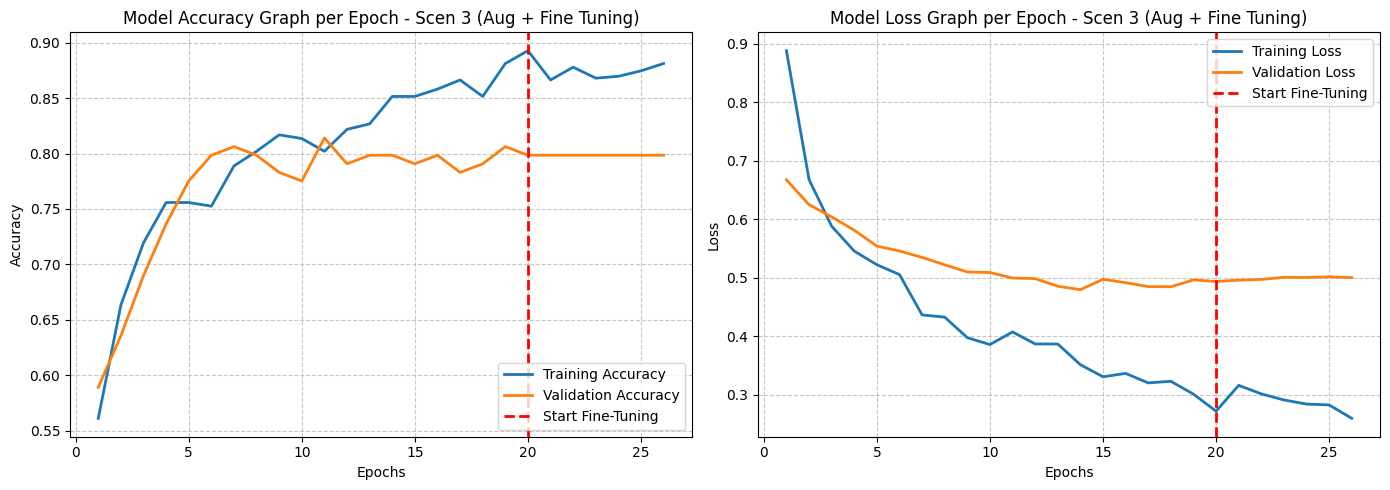

In [ ]:
# Creating Accuracy and Loss Graphs
import matplotlib.pyplot as plt

print("Accuracy and Loss Graphs (Phase 1 & Phase 2)")

# Combine Phase 1 and Phase 2 history data
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

epochs_range = range(1, len(acc) + 1)
phase1_len = len(history_phase1.history['accuracy'])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Accuracy
ax[0].plot(epochs_range, acc, label='Training Accuracy', linewidth=2, color='#1f77b4')
ax[0].plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, color='#ff7f0e')
ax[0].axvline(x=phase1_len, color='red', linestyle='--', linewidth=2, label='Start Fine-Tuning')

ax[0].set_title('Model Accuracy Graph per Epoch - Scen 3 (Aug + Fine Tuning)')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='lower right')
ax[0].grid(True, linestyle='--', alpha=0.7)

# Graph 2: Loss
ax[1].plot(epochs_range, loss, label='Training Loss', linewidth=2, color='#1f77b4')
ax[1].plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, color='#ff7f0e')
ax[1].axvline(x=phase1_len, color='red', linestyle='--', linewidth=2, label='Start Fine-Tuning')

ax[1].set_title('Model Loss Graph per Epoch - Scen 3 (Aug + Fine Tuning)')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='upper right')
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Save graph image
plt.savefig("grafik_loss_accuracy_gabungan_default.png", dpi=300)
plt.show()

Locating misclassified images...
Found 17 misclassified images.


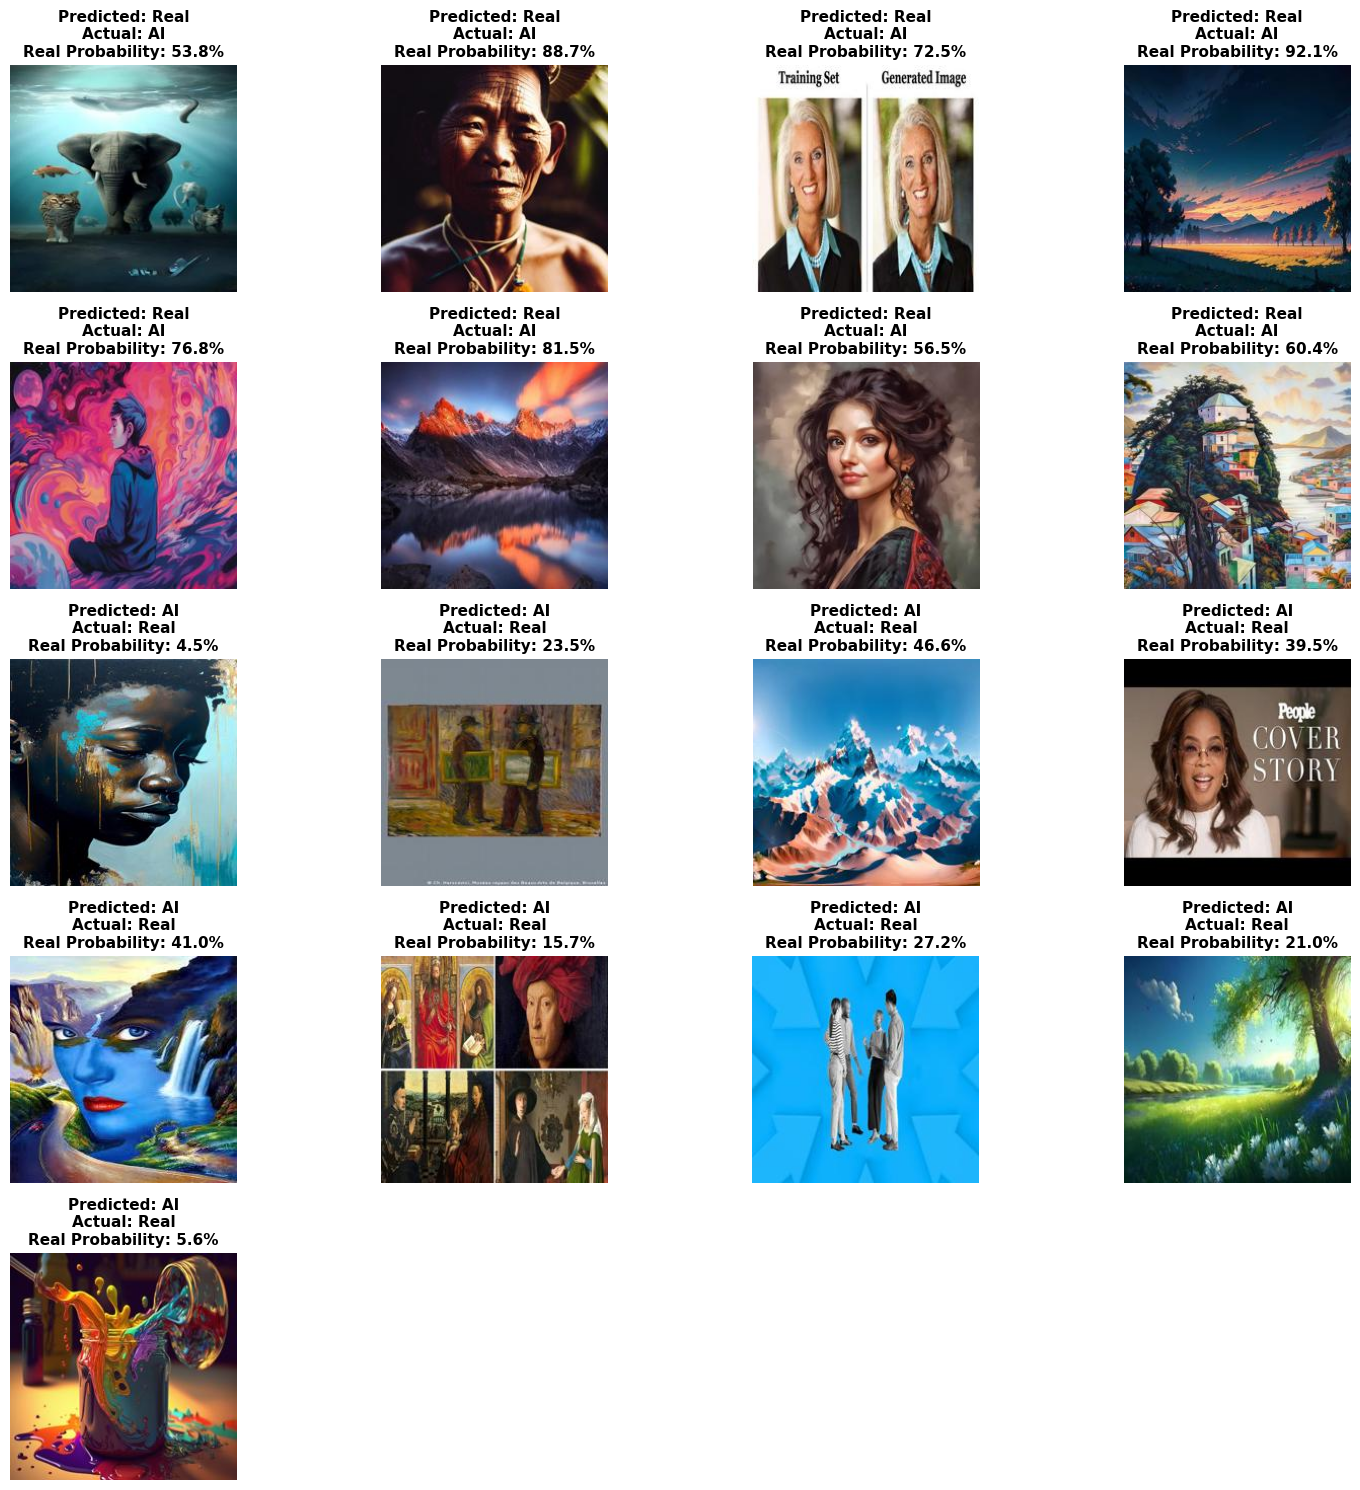

In [ ]:
# Misclassified Images Visualization with Probability
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

print("Locating misclassified images...")

misclassified_indices = np.where(y_true != y_pred)[0]

print(f"Found {len(misclassified_indices)} misclassified images.")

# Mengambil path file asli dari dataset raw
file_paths = test_dataset_raw.file_paths

# Menyiapkan kanvas gambar
plt.figure(figsize=(15, 15))

for i, idx in enumerate(misclassified_indices):
    if i >= 17:
        break

    plt.subplot(5, 4, i + 1)

    # Load gambar
    img = tf.keras.utils.load_img(file_paths[idx])
    plt.imshow(img)

    # Mengambil teks kelas
    true_label_name = class_names[y_true[idx]]
    pred_label_name = class_names[y_pred[idx]]

    # Mengambil nilai probabilitas Real
    prob_real = y_pred_probs[idx][0] * 100

    plt.title(f"Predicted: {pred_label_name}\nActual: {true_label_name}\nReal Probability: {prob_real:.1f}%",
              color="black", fontsize=11, fontweight="bold")

    plt.axis("off")

plt.tight_layout()

# Menyimpan hasil
plt.savefig("misclassified_images_scenario3.png", dpi=300)
plt.show()